In [2]:


!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [3]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)


Device Available:  cuda


In [4]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['wild' 'cat' 'dog']


,image_path,labels
0,/content/animal-faces/afhq/train/wild/flickr_w...,wild
1,/content/animal-faces/afhq/train/wild/flickr_w...,wild
2,/content/animal-faces/afhq/train/wild/flickr_w...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/flickr_w...,wild


In [5]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [6]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

# Define separate transforms for training and validation/testing
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

val_test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [7]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [8]:
train_dataset = CustomImageDataset(dataframe = train, transform = train_transform)
test_dataset = CustomImageDataset(dataframe = test, transform = val_test_transform)
val_dataset = CustomImageDataset(dataframe = val, transform = val_test_transform)

In [9]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/dog/pixabay_dog_000018.jpg


In [10]:

train_dataset.__getitem__(2)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
 tensor(1, device='cuda:0'))

In [11]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

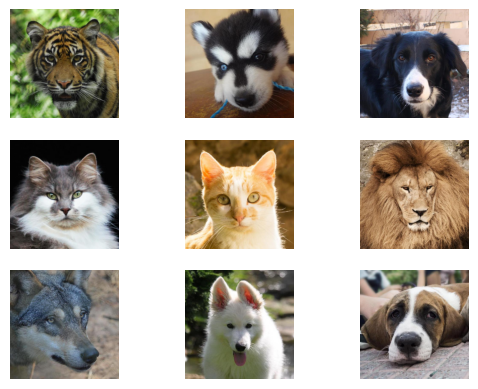

In [12]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [13]:

LR = 1e-4
BATCH_SIZE = 20
EPOCHS = 16

In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [28]:
import torchvision.models as models

# Load a pre-trained ResNet-50 model
# Set pretrained=True to load weights trained on ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all parameters in the pre-trained model
for param in model.parameters():
    param.requires_grad = False

# Modify the final classification layer
num_ftrs = model.fc.in_features
# Our dataset has 3 unique labels: 'cat', 'dog', 'wild'
model.fc = nn.Linear(num_ftrs, len(data_df['labels'].unique()))

# Move the model to the appropriate device (GPU if available, else CPU)
model = model.to(device)

print("Pre-trained ResNet-50 model loaded and adapted.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Pre-trained ResNet-50 model loaded and adapted.


In [29]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           9,408
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]           4,096
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]          16,384
      BatchNorm2d-12          [-1, 256, 32, 32]             512
           Conv2d-13          [-1, 256, 32, 32]          16,384
      BatchNorm2d-14          [-1, 256,

In [30]:
import torch.optim.lr_scheduler as lr_scheduler

criterion = nn.CrossEntropyLoss()

# Only optimize parameters that are unfrozen (i.e., the new fc layer)
optimizer = Adam(model.fc.parameters(), lr = LR)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

print("Criterion, Optimizer, and Scheduler for the model initialized.")

Criterion, Optimizer, and Scheduler for the model initialized.


In [31]:
import copy

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

# Early stopping parameters for the model
best_val_loss = float('inf')
patience = 10 # Number of epochs to wait for improvement
patience_counter = 0

best_model_wts = copy.deepcopy(model.state_dict()) # To save the best model weights

print("Starting training for the model...")

for epoch in range(EPOCHS):
  model.train() # Set model to training mode
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad() # Zero the gradients
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval() # Set model to evaluation mode
  total_loss_val = 0
  total_acc_val = 0
  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  avg_train_loss = total_loss_train / len(train_loader.dataset)
  avg_val_loss = total_loss_val / len(val_loader.dataset)

  total_loss_train_plot.append(avg_train_loss)
  total_loss_validation_plot.append(avg_val_loss)

  total_acc_train_plot.append(round((total_acc_train/len(train_loader.dataset)) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/len(val_loader.dataset)) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {avg_train_loss:.4f} Train Accuracy {round((total_acc_train/len(train_loader.dataset)) * 100, 4):.2f}
            Validation Loss {avg_val_loss:.4f} Validation Accuracy {round((total_acc_val/len(val_loader.dataset)) * 100, 4):.2f}
        ''')

  # Learning Rate Scheduler step
  scheduler.step(avg_val_loss)

  # Early Stopping logic
  if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      patience_counter = 0
      best_model_wts = copy.deepcopy(model.state_dict()) # Save best model
  else:
      patience_counter += 1
      if patience_counter >= patience:
          print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss.")
          break

# Load the best model weights after training (due to early stopping)
model.load_state_dict(best_model_wts)
print("Loaded best model weights.")

Starting training for the model...
Epoch 1/16,
            Train Loss: 0.0194 Train Accuracy 90.14
            Validation Loss 0.0054 Validation Accuracy 98.51
        
Epoch 2/16,
            Train Loss: 0.0097 Train Accuracy 94.63
            Validation Loss 0.0034 Validation Accuracy 98.72
        
Epoch 3/16,
            Train Loss: 0.0079 Train Accuracy 95.00
            Validation Loss 0.0026 Validation Accuracy 98.84
        
Epoch 4/16,
            Train Loss: 0.0069 Train Accuracy 95.49
            Validation Loss 0.0021 Validation Accuracy 98.93
        
Epoch 5/16,
            Train Loss: 0.0063 Train Accuracy 95.81
            Validation Loss 0.0019 Validation Accuracy 98.88
        
Epoch 6/16,
            Train Loss: 0.0066 Train Accuracy 95.65
            Validation Loss 0.0016 Validation Accuracy 99.09
        
Epoch 7/16,
            Train Loss: 0.0060 Train Accuracy 96.08
            Validation Loss 0.0016 Validation Accuracy 99.17
        
Epoch 8/16,
            Tra

In [32]:
print("Evaluating the model on test set...")
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Model Test Accuracy: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Test Loss: {round(total_loss_test/1000, 4)}")

Evaluating the model on test set...
Model Test Accuracy: 99.2559 and Test Loss: 0.0037


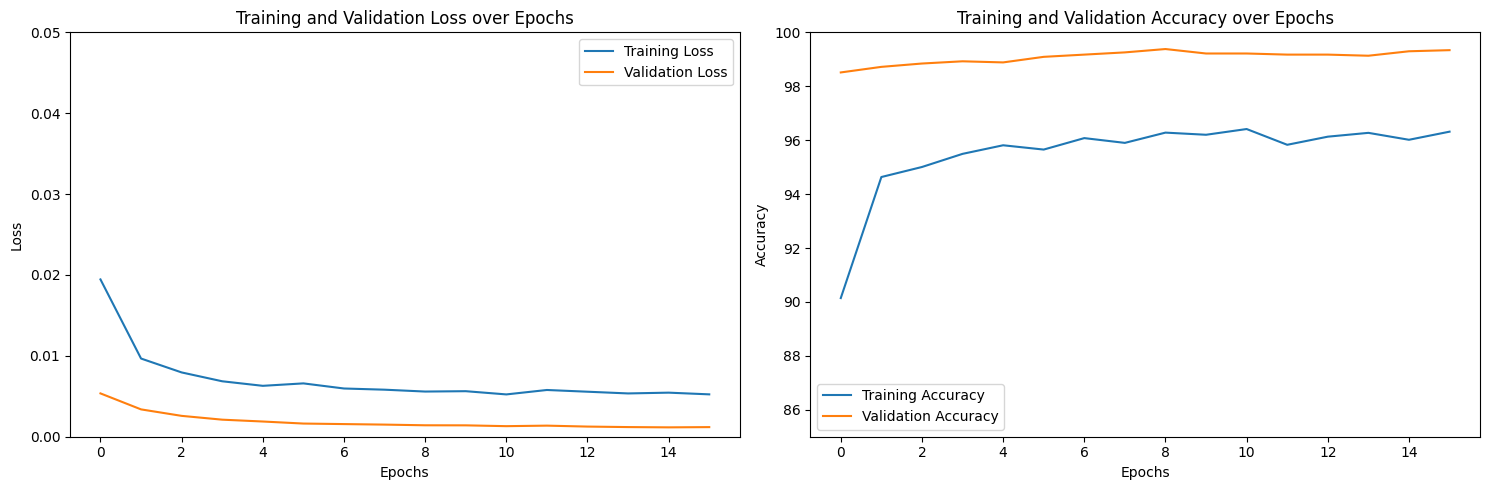

In [33]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim(0, 0.05) # Maintain y-axis limits for consistency
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim(85, 100) # Maintain y-axis limits for consistency
axs[1].legend()

plt.tight_layout()
plt.show()

In [44]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = val_test_transform(image).to(device)

  # Ensure the model is in evaluation mode
  model.eval()

  with torch.no_grad():
    output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])


print("\nPredicting with the trained model for /content/anjing.jpg:")
print(predict_image("/content/anjing.jpg"))

print("\nPredicting with the trained model for /content/macam.jpg:")
print(predict_image("/content/macam.jpg"))


Predicting with the trained model for /content/anjing.jpg:
['dog']

Predicting with the trained model for /content/macam.jpg:
['wild']


In [35]:
import torchvision.models as models

# Load a pre-trained ResNet-50 model
# Set pretrained=True to load weights trained on ImageNet
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all parameters in the pre-trained model
for param in resnet_model.parameters():
    param.requires_grad = False

# Modify the final classification layer
num_ftrs = resnet_model.fc.in_features
# Our dataset has 3 unique labels: 'cat', 'dog', 'wild'
resnet_model.fc = nn.Linear(num_ftrs, len(data_df['labels'].unique()))

# Move the model to the appropriate device (GPU if available, else CPU)
resnet_model = resnet_model.to(device)

print("Pre-trained ResNet-50 model loaded and adapted.")

Pre-trained ResNet-50 model loaded and adapted.


In [36]:
import torch.optim.lr_scheduler as lr_scheduler

# Define loss function, optimizer, and scheduler for the ResNet model
criterion_resnet = nn.CrossEntropyLoss()

# Only optimize parameters that are unfrozen (i.e., the new fc layer)
optimizer_resnet = Adam(resnet_model.fc.parameters(), lr = LR)
scheduler_resnet = lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=5)

print("Criterion, Optimizer, and Scheduler for ResNet model initialized.")

Criterion, Optimizer, and Scheduler for ResNet model initialized.


In [37]:
import copy

total_loss_train_plot_resnet = []
total_loss_validation_plot_resnet = []
total_acc_train_plot_resnet = []
total_acc_validation_plot_resnet = []

# Early stopping parameters for ResNet model
best_val_loss_resnet = float('inf')
patience_resnet = 10 # Number of epochs to wait for improvement
patience_counter_resnet = 0

best_model_wts_resnet = copy.deepcopy(resnet_model.state_dict()) # To save the best model weights

print("Starting training for ResNet-50 model...")

for epoch in range(EPOCHS):
  resnet_model.train() # Set model to training mode
  total_acc_train_resnet = 0
  total_loss_train_resnet = 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_resnet.zero_grad() # Zero the gradients
    outputs = resnet_model(inputs)
    train_loss_resnet = criterion_resnet(outputs, labels)
    total_loss_train_resnet += train_loss_resnet.item()

    train_loss_resnet.backward()
    optimizer_resnet.step()

    train_acc_resnet = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train_resnet += train_acc_resnet

  resnet_model.eval() # Set model to evaluation mode
  total_loss_val_resnet = 0
  total_acc_val_resnet = 0
  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = resnet_model(inputs)
      val_loss_resnet = criterion_resnet(outputs, labels)
      total_loss_val_resnet += val_loss_resnet.item()

      val_acc_resnet = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val_resnet += val_acc_resnet

  avg_train_loss_resnet = total_loss_train_resnet / len(train_loader.dataset)
  avg_val_loss_resnet = total_loss_val_resnet / len(val_loader.dataset)

  total_loss_train_plot_resnet.append(avg_train_loss_resnet)
  total_loss_validation_plot_resnet.append(avg_val_loss_resnet)

  total_acc_train_plot_resnet.append(round((total_acc_train_resnet/len(train_loader.dataset)) * 100, 4))
  total_acc_validation_plot_resnet.append(round((total_acc_val_resnet/len(val_loader.dataset)) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {avg_train_loss_resnet:.4f} Train Accuracy {round((total_acc_train_resnet/len(train_loader.dataset)) * 100, 4):.2f}
            Validation Loss {avg_val_loss_resnet:.4f} Validation Accuracy {round((total_acc_val_resnet/len(val_loader.dataset)) * 100, 4):.2f}
        ''')

  # Learning Rate Scheduler step
  scheduler_resnet.step(avg_val_loss_resnet)

  # Early Stopping logic
  if avg_val_loss_resnet < best_val_loss_resnet:
      best_val_loss_resnet = avg_val_loss_resnet
      patience_counter_resnet = 0
      best_model_wts_resnet = copy.deepcopy(resnet_model.state_dict()) # Save best model
  else:
      patience_counter_resnet += 1
      if patience_counter_resnet >= patience_resnet:
          print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss.")
          break

# Load the best model weights after training (due to early stopping)
resnet_model.load_state_dict(best_model_wts_resnet)
print("Loaded best ResNet-50 model weights.")

Starting training for ResNet-50 model...
Epoch 1/16,
            Train Loss: 0.0211 Train Accuracy 88.34
            Validation Loss 0.0055 Validation Accuracy 98.76
        
Epoch 2/16,
            Train Loss: 0.0098 Train Accuracy 94.42
            Validation Loss 0.0033 Validation Accuracy 98.88
        
Epoch 3/16,
            Train Loss: 0.0078 Train Accuracy 95.02
            Validation Loss 0.0024 Validation Accuracy 98.97
        
Epoch 4/16,
            Train Loss: 0.0070 Train Accuracy 95.55
            Validation Loss 0.0022 Validation Accuracy 98.93
        
Epoch 5/16,
            Train Loss: 0.0065 Train Accuracy 95.49
            Validation Loss 0.0018 Validation Accuracy 99.05
        
Epoch 6/16,
            Train Loss: 0.0062 Train Accuracy 95.96
            Validation Loss 0.0016 Validation Accuracy 99.17
        
Epoch 7/16,
            Train Loss: 0.0059 Train Accuracy 96.09
            Validation Loss 0.0014 Validation Accuracy 99.05
        
Epoch 8/16,
         

In [38]:
print("Evaluating ResNet-50 model on test set...")
with torch.no_grad():
  total_loss_test_resnet = 0
  total_acc_test_resnet = 0
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    predictions_resnet = resnet_model(inputs)

    acc_resnet = (torch.argmax(predictions_resnet, axis = 1) == labels).sum().item()
    total_acc_test_resnet += acc_resnet
    test_loss_resnet = criterion_resnet(predictions_resnet, labels)
    total_loss_test_resnet += test_loss_resnet.item()

print(f"ResNet-50 Model Test Accuracy: {round((total_acc_test_resnet/test_dataset.__len__()) * 100, 4)} and Test Loss: {round(total_loss_test_resnet/1000, 4)}")

Evaluating ResNet-50 model on test set...
ResNet-50 Model Test Accuracy: 99.1319 and Test Loss: 0.0038


Terakhir, mari kita visualisasikan kurva pelatihan untuk model ResNet-50 dan coba prediksi dengan model yang baru.

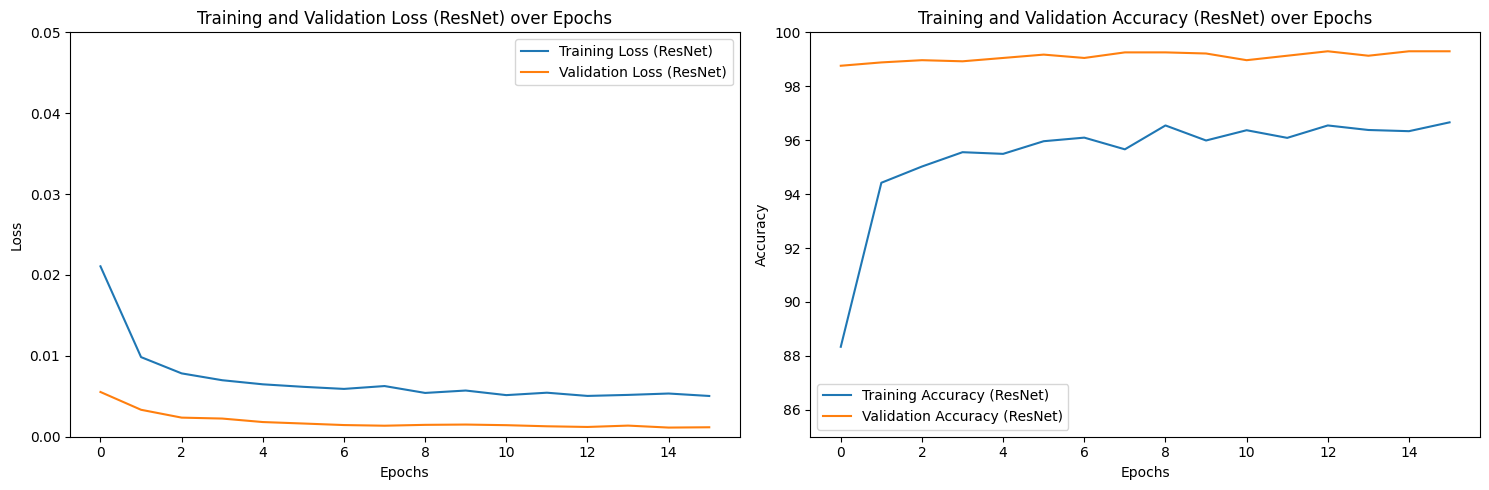

In [39]:
fig_resnet, axs_resnet = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs_resnet[0].plot(total_loss_train_plot_resnet, label = 'Training Loss (ResNet)')
axs_resnet[0].plot(total_loss_validation_plot_resnet, label = 'Validation Loss (ResNet)')
axs_resnet[0].set_title('Training and Validation Loss (ResNet) over Epochs')
axs_resnet[0].set_xlabel('Epochs')
axs_resnet[0].set_ylabel('Loss')
axs_resnet[0].set_ylim(0, 0.05) # Maintain y-axis limits for consistency
axs_resnet[0].legend()

axs_resnet[1].plot(total_acc_train_plot_resnet, label = 'Training Accuracy (ResNet)')
axs_resnet[1].plot(total_acc_validation_plot_resnet, label = 'Validation Accuracy (ResNet)')
axs_resnet[1].set_title('Training and Validation Accuracy (ResNet) over Epochs')
axs_resnet[1].set_xlabel('Epochs')
axs_resnet[1].set_ylabel('Accuracy')
axs_resnet[1].set_ylim(85, 100) # Maintain y-axis limits for consistency
axs_resnet[1].legend()

plt.tight_layout()
plt.show()

In [45]:
def predict_image_resnet(image_path):
  image = Image.open(image_path).convert('RGB')
  image = val_test_transform(image).to(device)

  # Ensure the model is in evaluation mode
  resnet_model.eval()

  with torch.no_grad():
    output = resnet_model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])



print("\nPredicting with ResNet-50 model for /content/anjing.jpg:")
print(predict_image_resnet("/content/anjing.jpg"))

print("\nPredicting with ResNet-50 model for /content/macam.jpg:")
print(predict_image_resnet("/content/macam.jpg"))


Predicting with ResNet-50 model for /content/anjing.jpg:
['dog']

Predicting with ResNet-50 model for /content/macam.jpg:
['wild']


In [41]:
# Save the ResNet-50 model
resnet_model_save_path = 'fine_tuned_resnet50_animal_classifier.pth'
torch.save(resnet_model.state_dict(), resnet_model_save_path)
print(f"Fine-tuned ResNet-50 model saved to {resnet_model_save_path}")

Fine-tuned ResNet-50 model saved to fine_tuned_resnet50_animal_classifier.pth


In [42]:
import torch

# Define the path where you want to save the model
model_save_path = 'fine_tuned_resnet50_animal_classifier.pth'

# Save the model's state_dict
torch.save(model.state_dict(), model_save_path)

print(f"Fine-tuned model saved to {model_save_path}")

Fine-tuned model saved to fine_tuned_resnet50_animal_classifier.pth


In [43]:
from google.colab import files
files.download("fine_tuned_resnet50_animal_classifier.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>